## Comparative Multi-Team EDA

---
## Step 1 - Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

TITLE_TEAMS = ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']

TEAM_PALETTE = {
    'Arsenal':            '#EF0107',
    'Liverpool':          '#00B2A9',
    'Manchester City':    '#6CABDD',
    'Manchester United':  '#FFB81C',
}

STAKES_PALETTE = {'High Stakes': '#EF0107', 'Normal': '#9C824A'}

SEASON_LABELS = {
    1920: '19-20', 2021: '20-21', 2122: '21-22',
    2223: '22-23', 2324: '23-24', 2425: '24-25', 2526: '25-26'
}

BIG6 = {'Arsenal', 'Liverpool', 'Manchester City', 'Manchester United', 'Chelsea', 'Tottenham'}

print('Imports ready')

Imports ready


---
## Step 2 - Load Data

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(PROC_DATA_DIR / 'all_4teams_processed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['team', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Teams: {sorted(df["team"].unique())}')

Shape: (1064, 37)
Teams: ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']


---
## Quick Data Overview

In [3]:
# check is_high_stakes_retro sits at 10/38 per team-season
# check mean stakes_intensity within the retro bucket per team-season (absolute-intensity caveat)
retro_counts = df.groupby(['team','season'])['is_high_stakes_retro'].sum().unstack()
print('is_high_stakes_retro matches per team per season (should all read 10): ')
print(retro_counts)

is_high_stakes_retro matches per team per season (should all read 10): 
season             1920  2021  2122  2223  2324  2425  2526
team                                                       
Arsenal              10    10    10    10    10    10    10
Liverpool            10    10    10    10    10    10    10
Manchester City      10    10    10    10    10    10    10
Manchester United    10    10    10    10    10    10    10


In [5]:
hs = df[df['is_high_stakes_retro']]
intensity_within_bucket = hs.groupby(['team','season'])['stakes_intensity'].mean().unstack()
print('Mean stakes_intensity within the retro high-stakes bucket, per team-season:')
print(intensity_within_bucket.round(3))

Mean stakes_intensity within the retro high-stakes bucket, per team-season:
season              1920   2021   2122   2223   2324   2425   2526
team                                                              
Arsenal            0.464  0.443  0.629  0.825  0.850  0.684  0.964
Liverpool          0.956  0.623  0.851  0.502  0.825  0.955  0.658
Manchester City    0.663  0.946  0.956  0.935  0.947  0.660  0.786
Manchester United  0.651  0.664  0.551  0.541  0.492  0.364  0.650


---
## Section B - Is the Bottle Gap Unique to Arsenal?

---
## Chart B1 - The Bottle Gap Matrix (All Four Teams)

In [8]:
# high-stakes-retro PPG minus season-baseline PPG, per team per season
# 2x2 grid of subplots, one per team
season_ppg = df.groupby(['team', 'season'])['points'].mean()
hs_ppg = df[df['is_high_stakes_retro']].groupby(['team', 'season'])['points'].mean()

ppg_gap = pd.concat([season_ppg.rename('season_ppg'), hs_ppg.rename('hs_ppg')], axis=1)
ppg_gap['gap'] = ppg_gap['hs_ppg'] - ppg_gap['season_ppg']
ppg_gap = ppg_gap.reset_index()
ppg_gap['season_label'] = ppg_gap['season'].map(SEASON_LABELS)

print(ppg_gap.round(3).to_string(index=False))

             team  season  season_ppg  hs_ppg    gap season_label
          Arsenal    1920       1.474     1.7  0.226        19-20
          Arsenal    2021       1.605     1.8  0.195        20-21
          Arsenal    2122       1.816     1.2 -0.616        21-22
          Arsenal    2223       2.211     2.1 -0.111        22-23
          Arsenal    2324       2.342     2.5  0.158        23-24
          Arsenal    2425       1.947     1.9 -0.047        24-25
          Arsenal    2526       2.237     2.4  0.163        25-26
        Liverpool    1920       2.605     2.0 -0.605        19-20
        Liverpool    2021       1.816     2.0  0.184        20-21
        Liverpool    2122       2.421     2.6  0.179        21-22
        Liverpool    2223       1.763     2.4  0.637        22-23
        Liverpool    2324       2.158     2.0 -0.158        23-24
        Liverpool    2425       2.211     1.7 -0.511        24-25
        Liverpool    2526       1.579     1.4 -0.179        25-26
  Manchest

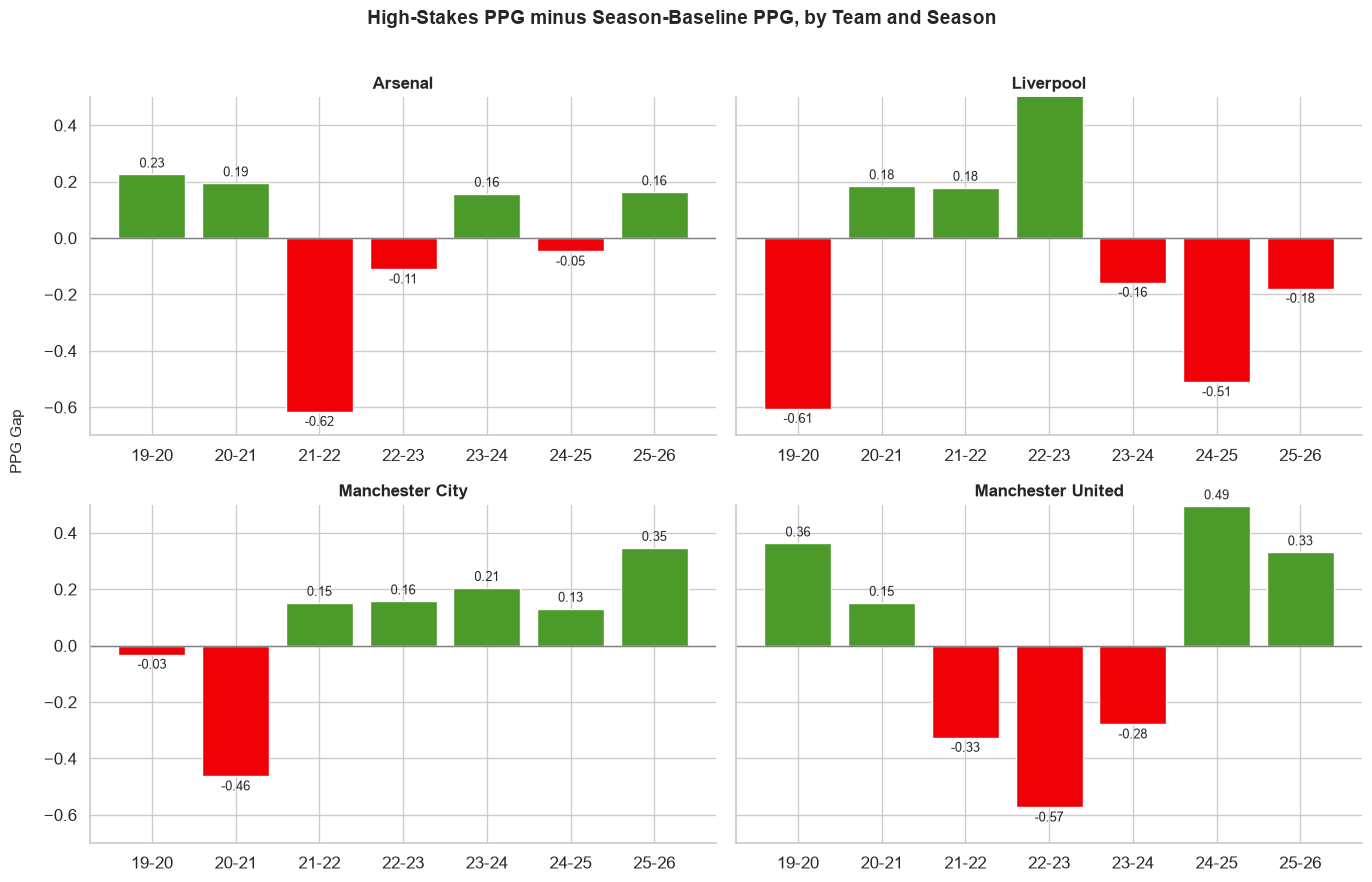

In [10]:
fig, axes = plt.subplots(2, 2, figsize = (14,9), sharey = True)

for ax, team in zip(axes.flat, TITLE_TEAMS):
    team_df = ppg_gap[ppg_gap['team'] == team].sort_values('season')
    colors = ['#EF0107' if g < 0 else '#4C9A2A' for g in team_df['gap']]
    bars = ax.bar(team_df['season_label'], team_df['gap'], color = colors)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.axhline(y=0, color='grey', linewidth=1)
    ax.set_title(team, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.7, 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('High-Stakes PPG minus Season-Baseline PPG, by Team and Season',
             fontsize=14, fontweight='bold')
fig.text(0.02, 0.5, 'PPG Gap', va='center', rotation='vertical', fontsize=11)
plt.tight_layout(rect=[0.03, 0, 1, 0.97])
plt.show()

### Reading Chart B1

---
## Chart B2 - Pressure Resilience Index

In [14]:
# mean PPG gap over contention seasons only (>=5 absolute high-stakes matches), per team
bucket_counts = (
    df.groupby(['team', 'season', 'is_high_stakes'])
    .size().unstack(fill_value=0)
    .rename(columns={False: 'n_normal', True: 'n_highstakes'})
)
contention = bucket_counts[bucket_counts['n_highstakes'] >= 5].reset_index()[['team', 'season']]

gap_contention = ppg_gap.merge(contention, on=['team', 'season'], how='inner')
resilience = gap_contention.groupby('team')['gap'].mean().sort_values(ascending=False)

print(bucket_counts)
print('Contention seasons per team:')
print(contention.groupby('team').size())
print()
print('Pressure Resilience Index (mean PPG gap, contention seasons only):')
print(resilience.round(3))

is_high_stakes            n_normal  n_highstakes
team              season                        
Arsenal           1920          35             3
                  2021          36             2
                  2122          30             8
                  2223          24            14
                  2324          23            15
                  2425          23            15
                  2526          21            17
Liverpool         1920          21            17
                  2021          25            13
                  2122          22            16
                  2223          35             3
                  2324          25            13
                  2425          20            18
                  2526          26            12
Manchester City   1920          25            13
                  2021          21            17
                  2122          20            18
                  2223          22            16
                  23

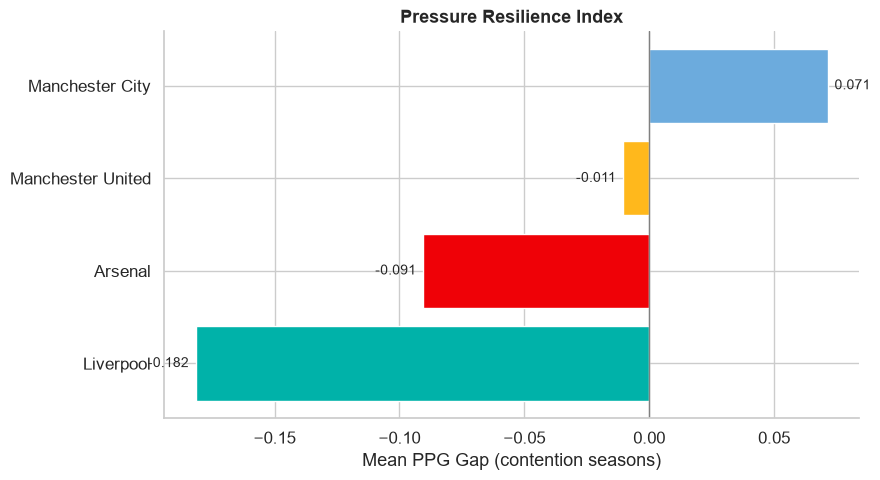

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = [TEAM_PALETTE[t] for t in resilience.index]
bars = ax.barh(resilience.index, resilience.values, color = colors)
ax.bar_label(bars, fmt = '%.3f', padding = 5, fontsize=10)
ax.axvline(x=0, color = 'grey', linewidth = 1)
ax.set_xlabel('Mean PPG Gap (contention seasons)')
ax.set_title('Pressure Resilience Index', fontsize = 13, fontweight = 'bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Reading Chart B2

---
## Section C - Does the xG-Stable / xGA-Soft Split Generalise?

---
## Chart C1 - xG and xGA Distributions, All Four Teams

In [20]:
# Welch's t-test per team, xG and xGA, high-stakes-retro vs normal
# 2x4 grid of violin plots: rows = xG/xGA, columns = team
ttest_rows=[]
for team in TITLE_TEAMS:
    t = df[df['team'] == team]
    hs_t = t[t['is_high_stakes_retro']]
    nm_t = t[~t['is_high_stakes_retro']]

    _, p_xg = stats.ttest_ind(hs_t['xG'], nm_t['xG'], equal_var=False)
    _, p_xga = stats.ttest_ind(hs_t['xGA'], nm_t['xGA'], equal_var=False)

    ttest_rows.append({
        'team': team,
        'xG_normal' : nm_t['xG'].mean(), 'xG_highstakes' : hs_t['xG'].mean(), 'xG_p': p_xg,
        'xGA_normal': nm_t['xGA'].mean(), 'xGA_highstakes': hs_t['xGA'].mean(), 'xGA_p': p_xga
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('team').round(3)
print(ttest_df)

                   xG_normal  xG_highstakes   xG_p  xGA_normal  \
team                                                             
Arsenal                1.783          1.843  0.665       1.053   
Liverpool              2.227          2.000  0.081       1.182   
Manchester City        2.247          2.276  0.842       1.007   
Manchester United      1.725          1.569  0.241       1.330   

                   xGA_highstakes  xGA_p  
team                                      
Arsenal                     1.321  0.031  
Liverpool                   1.247  0.576  
Manchester City             0.947  0.575  
Manchester United           1.603  0.032  


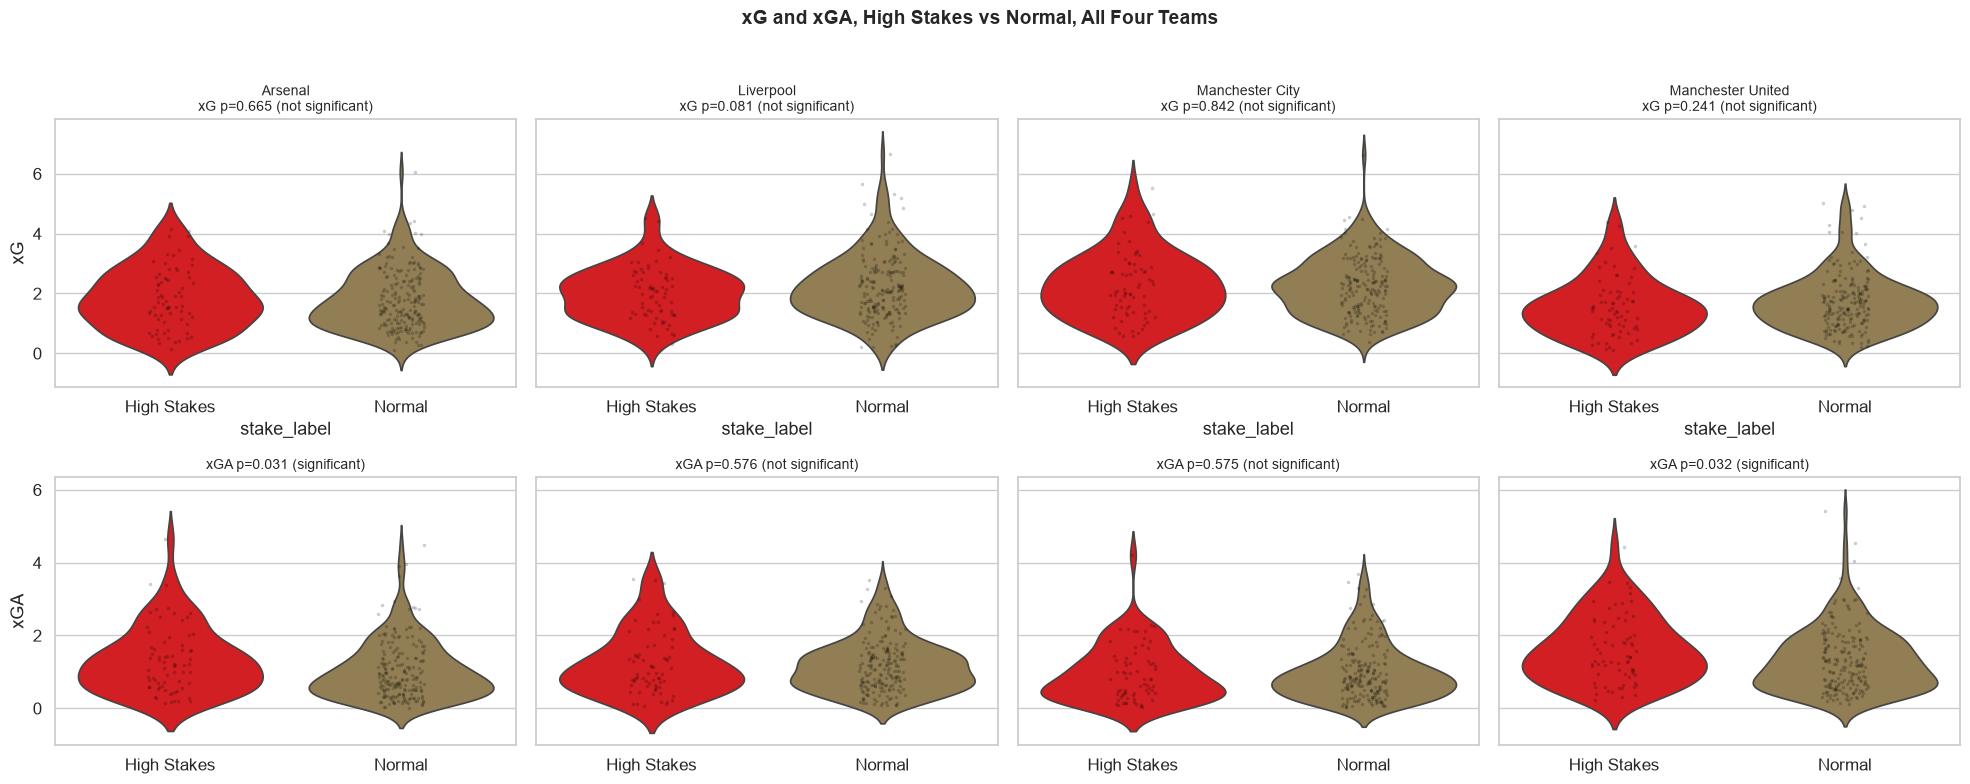

In [33]:
fig, axes = plt.subplots (2, 4, figsize = (20, 8), sharey = 'row')

for col,team in enumerate(TITLE_TEAMS):
    t = df[df['team'] == team].copy()
    t['stake_label'] = t['is_high_stakes_retro'].map({True: 'High Stakes', False: 'Normal'})

    ax_xg = axes[0,col]
    sns.violinplot(data=t, x = 'stake_label', y='xG', order = ['High Stakes', 'Normal'],
                  palette = STAKES_PALETTE, inner = None, ax = ax_xg)
    sns.stripplot(data=t, x= 'stake_label', y='xG', order = ['High Stakes', 'Normal'],
                 color = 'black', alpha = 0.2, size = 2.5, jitter = True, ax = ax_xg)
    p=ttest_df.loc[team,'xG_p']
    tag = 'significant' if p<0.05 else 'not significant'
    ax_xg.set_title(f'{team}\nxG p={p:.3f} ({tag})', fontsize=10)

    ax_xga = axes[1,col]
    sns.violinplot(data=t, x='stake_label', y='xGA', order=['High Stakes', 'Normal'],
                   palette=STAKES_PALETTE, inner=None, ax=ax_xga)
    sns.stripplot(data=t, x = 'stake_label', y = 'xGA', order = ['High Stakes', 'Normal'],
                 color = 'black', alpha = 0.2, size = 2.5, jitter = True, ax = ax_xga)
    p=ttest_df.loc[team, 'xGA_p']
    tag = 'significant' if p< 0.05 else 'not significant'
    ax_xga.set_title(f'xGA p={p:.3f} ({tag})', fontsize=10)
    ax_xga.set_xlabel('')
    ax_xga.set_ylabel('xGA' if col == 0 else '')

fig.suptitle('xG and xGA, High Stakes vs Normal, All Four Teams', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Reading Chart C1

---
## Section D - Win Rate Decay

---
## Chart D1 - Win Rate, Normal vs High Stakes, All Four Teams

In [39]:
# win rate per team, normal vs high-stakes-retro
win_rates = (
    df.groupby(['team','is_high_stakes_retro'])['points']
    .apply(lambda x: (x==3).mean())
    .unstack()
)
win_rates.columns = ['normal_winrate', 'highstakes_winrate']
win_rates['decay_pp'] = (win_rates['normal_winrate'] - win_rates['highstakes_winrate'])

print((win_rates*100).round(1))

                   normal_winrate  highstakes_winrate  decay_pp
team                                                           
Arsenal                      57.7                58.6      -0.9
Liverpool                    62.2                61.4       0.8
Manchester City              67.3                71.4      -4.1
Manchester United            48.0                47.1       0.8


### Reading Chart D1

---
## Section E - Flat-Track Bullies vs Big-Game Changers

---
## Chart E1 - Pressure PPG Gap by Opponent Tier

In [8]:
# per team: PPG gap (high-stakes-retro minus normal), split by Big6 vs Rest opponent


### Reading Chart E1

---
## Confounding Variables - What This Comparison Cannot Settle

---
## Key Findings Summary